In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import seaborn as sns

In [2]:
from io import BytesIO
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile

dataset_filename = "ObesityDataSet_raw_and_data_sinthetic.csv"
kaggle_path = Path(
    "/kaggle/input/datasets/fatemehmehrparvar/obesity-levels/"
    + dataset_filename
)

if kaggle_path.exists():
    df = pd.read_csv(kaggle_path)
else:
    dataset_url = (
        "https://archive.ics.uci.edu/static/public/544/"
        "estimation+of+obesity+levels+based+on+eating+habits+"
        "and+physical+condition.zip"
    )
    with urlopen(dataset_url) as response:
        archive_bytes = BytesIO(response.read())
    with ZipFile(archive_bytes) as archive:
        csv_path = next(
            name for name in archive.namelist()
            if name.endswith(dataset_filename)
        )
        with archive.open(csv_path) as csv_file:
            df = pd.read_csv(csv_file)

df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [4]:
df.shape

(2111, 17)

# Гипотезы
### 1. Логистическая регрессия покажет более высокое значение macro F1 на тестовой выборке, чем дерево решений, поскольку между признаками отсутствует сильная корреляция.
### 2. F1 macro мера не будет так сильно разниться с accuracy,из-за малого дисбаланса классов.
### 3. Логистическая регрессия с L1-регуляризацией покажет более высокий macro F1, чем с L2-регуляризацией, благодаря отбору признаков через зануление части коэффициентов.
### 4. Age,	Height, family_history_with_overweight должны быть самыми важными по feature importance дерева.
### 5. Глубина дерева 10 будет лучше глубины 15,т.к. структура не сильно сложная.

# 2. EDA

In [5]:
df.describe(include="all")

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Male,NaN,NaN,NaN,yes,yes,NaN,NaN,Sometimes,no,NaN,no,NaN,NaN,Sometimes,Public_Transportation,Obesity_Type_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


In [6]:
df.isna().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

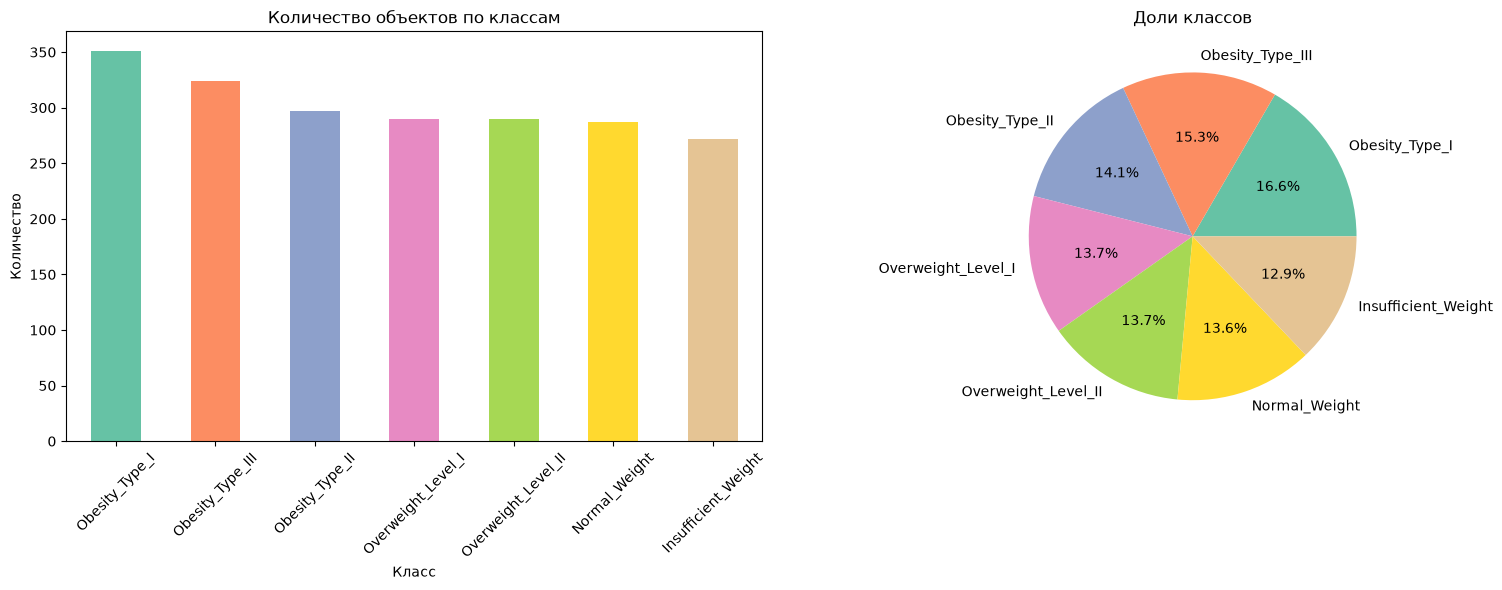

In [7]:
target_col = "NObeyesdad"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df[target_col].value_counts().plot.bar(
    ax=axes[0],
    color=sns.color_palette("Set2"))
axes[0].set_title("Количество объектов по классам")
axes[0].set_xlabel("Класс")
axes[0].set_ylabel("Количество")
axes[0].tick_params(axis="x", rotation=45)
df[target_col].value_counts(normalize=True).plot.pie(
    ax=axes[1],
    autopct="%1.1f%%",
    colors=sns.color_palette("Set2"))
axes[1].set_ylabel("")
axes[1].set_title("Доли классов")
plt.tight_layout()
plt.show()

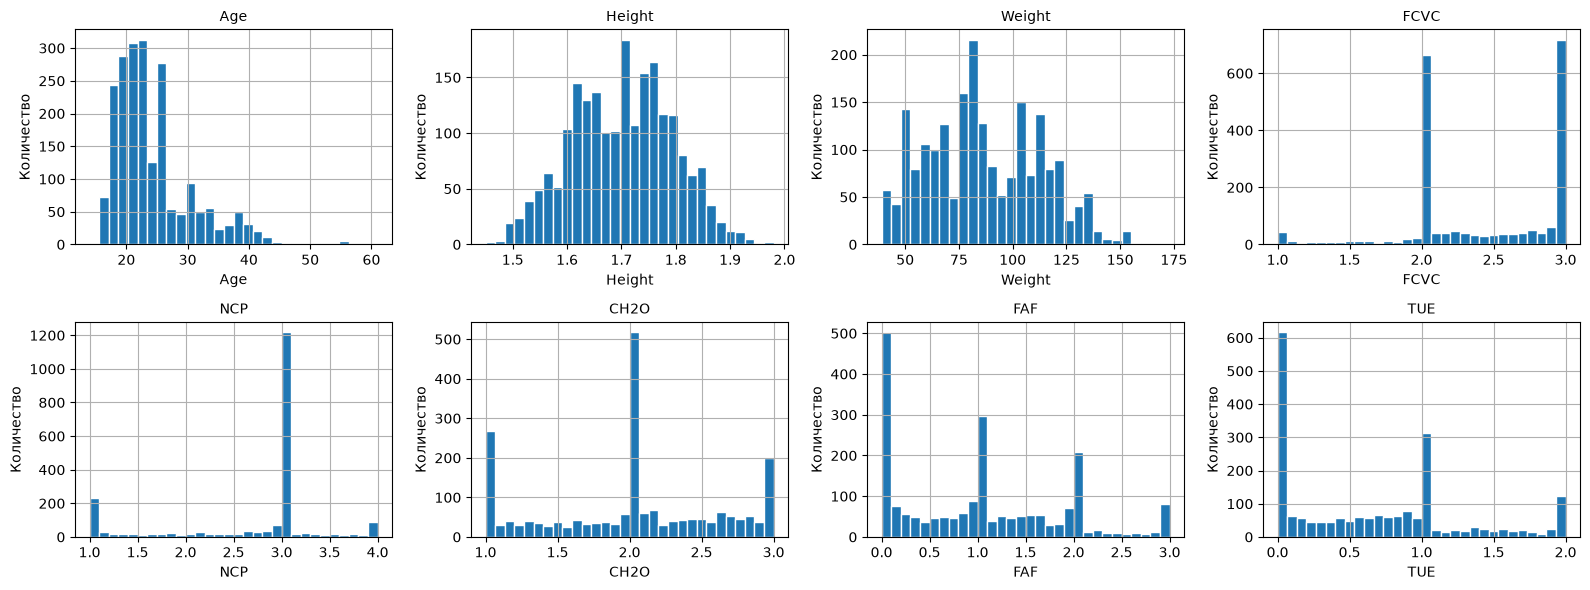

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(
    n_rows,
    4,
    figsize=(16, n_rows * 3)
)
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    df[col].hist(
        bins=30,
        ax=axes[i],
        edgecolor="white"
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Количество")
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()

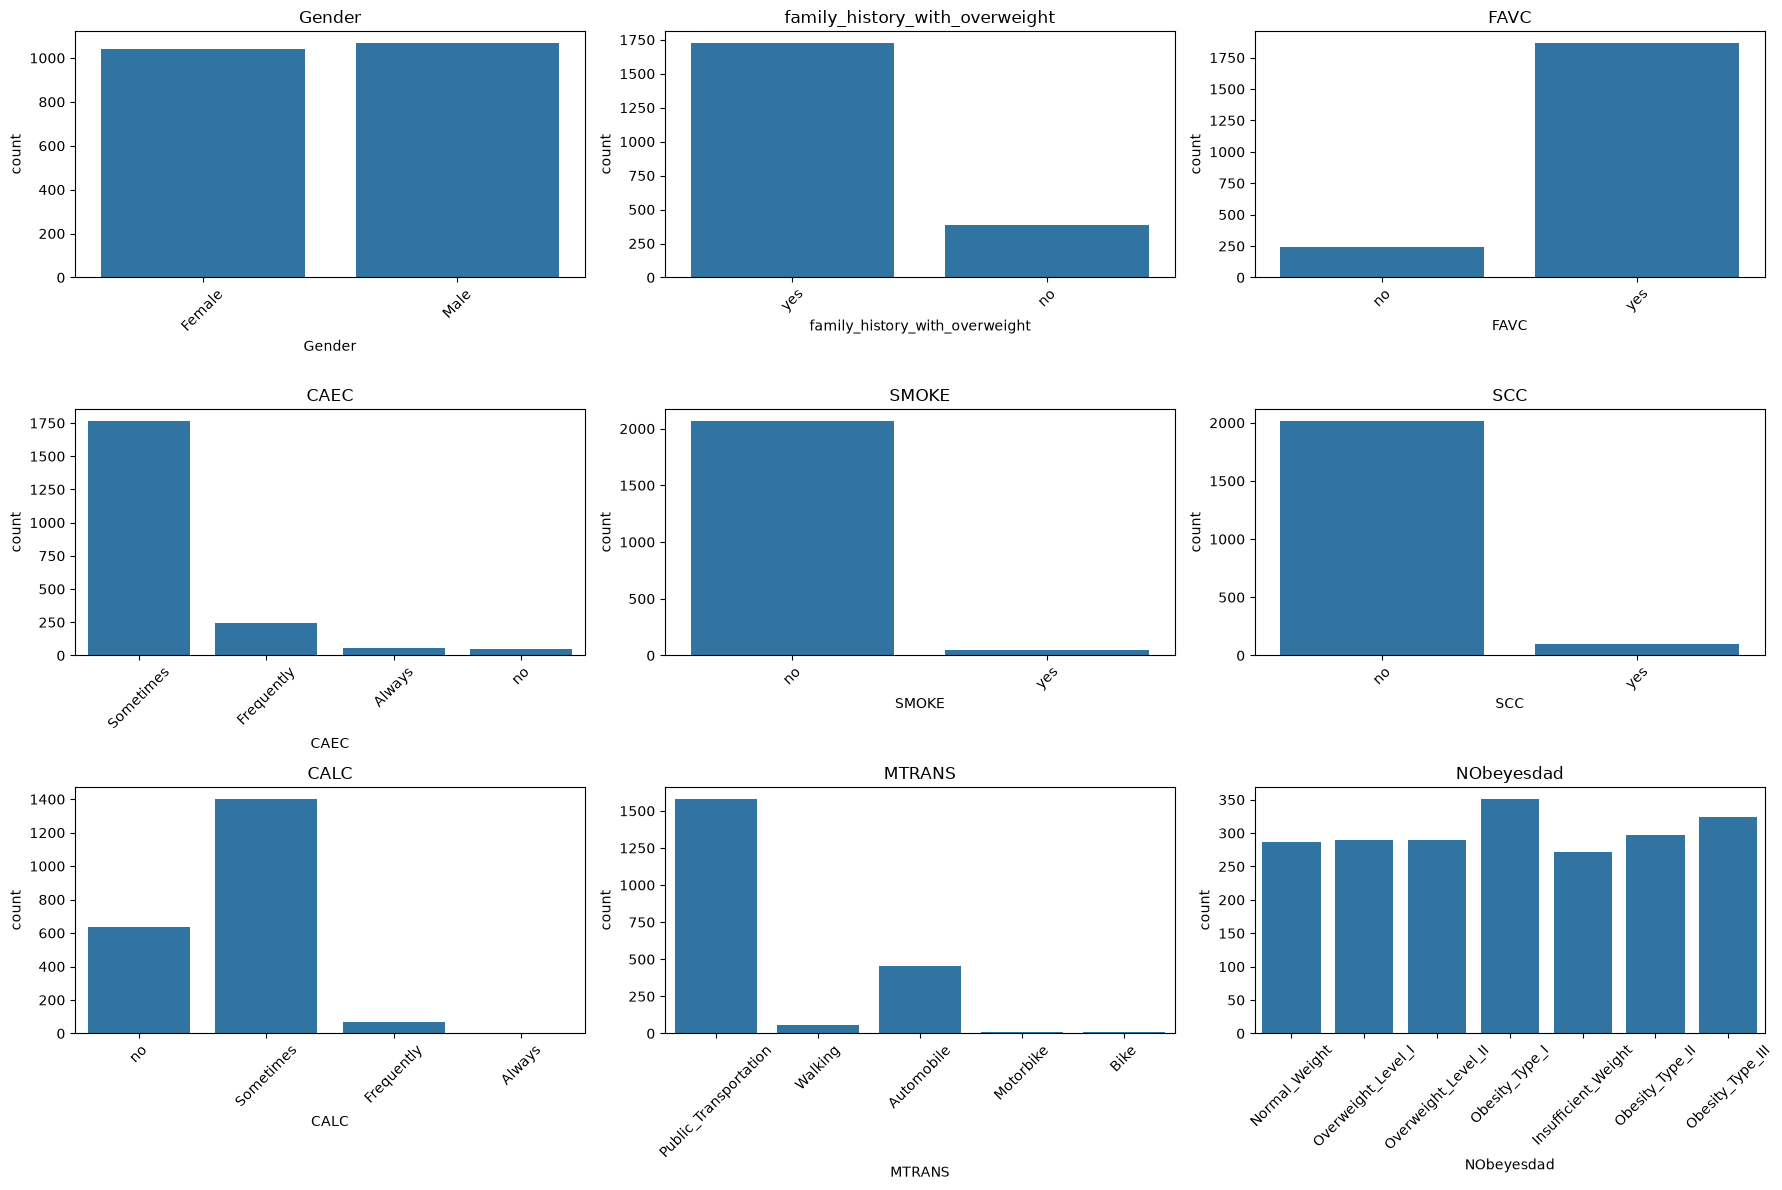

In [9]:
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

n_cols = len(categorical_cols)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(
    n_rows,
    3,
    figsize=(18, n_rows * 4)
)

axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


# Потенциально стоит удалить SMOKE так как оно может не влиять на ответ. Во всем остальном не заметил ничего странного.

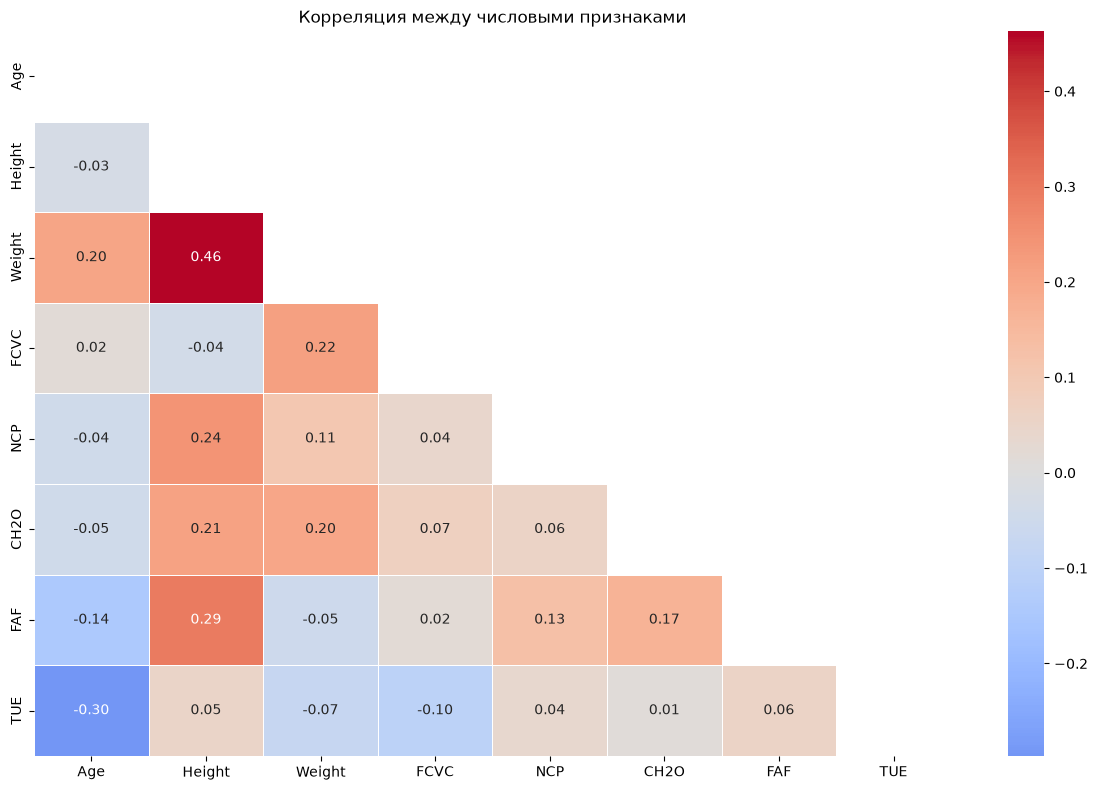

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5)
plt.title("Корреляция между числовыми признаками")
plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import chi2_contingency
def cramers_v(x, y):
    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()
    phi2 = chi2 / n
    r, k = table.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))
target_col = "NObeyesdad"
categorical_cols = df.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()
categorical_cols.remove(target_col)
for col in categorical_cols:
    score = cramers_v(df[col], df[target_col])
    print(f"{col:35s}: {score:.3f}")


Gender                             : 0.558
family_history_with_overweight     : 0.543
FAVC                               : 0.332
CAEC                               : 0.356
SMOKE                              : 0.123
SCC                                : 0.241
CALC                               : 0.231
MTRANS                             : 0.186


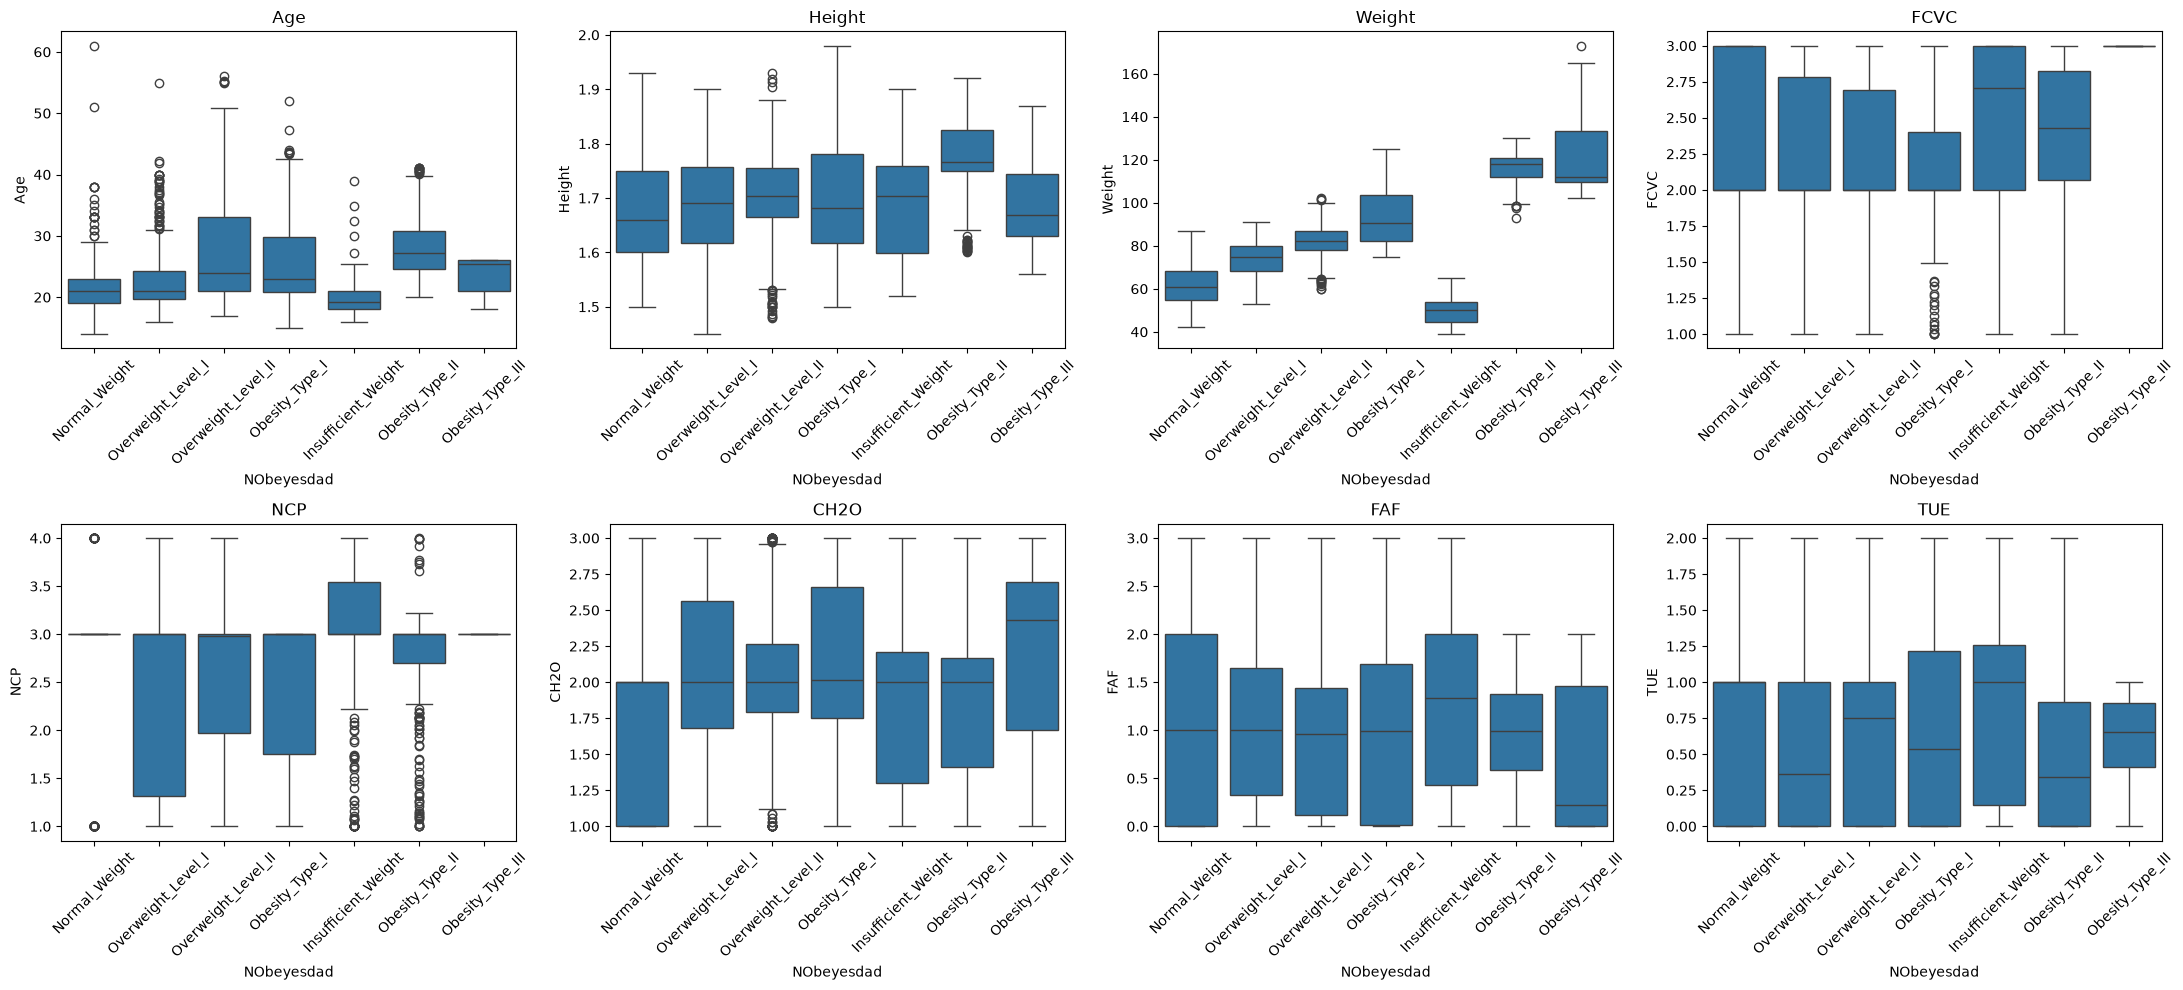

In [12]:
target_col = "NObeyesdad"
numeric_cols = df.select_dtypes(include="number").columns.tolist()
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    sns.boxplot(
        data=df,
        x=target_col,
        y=col,
        ax=axes[idx]
    )
    axes[idx].set_title(col)
    axes[idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

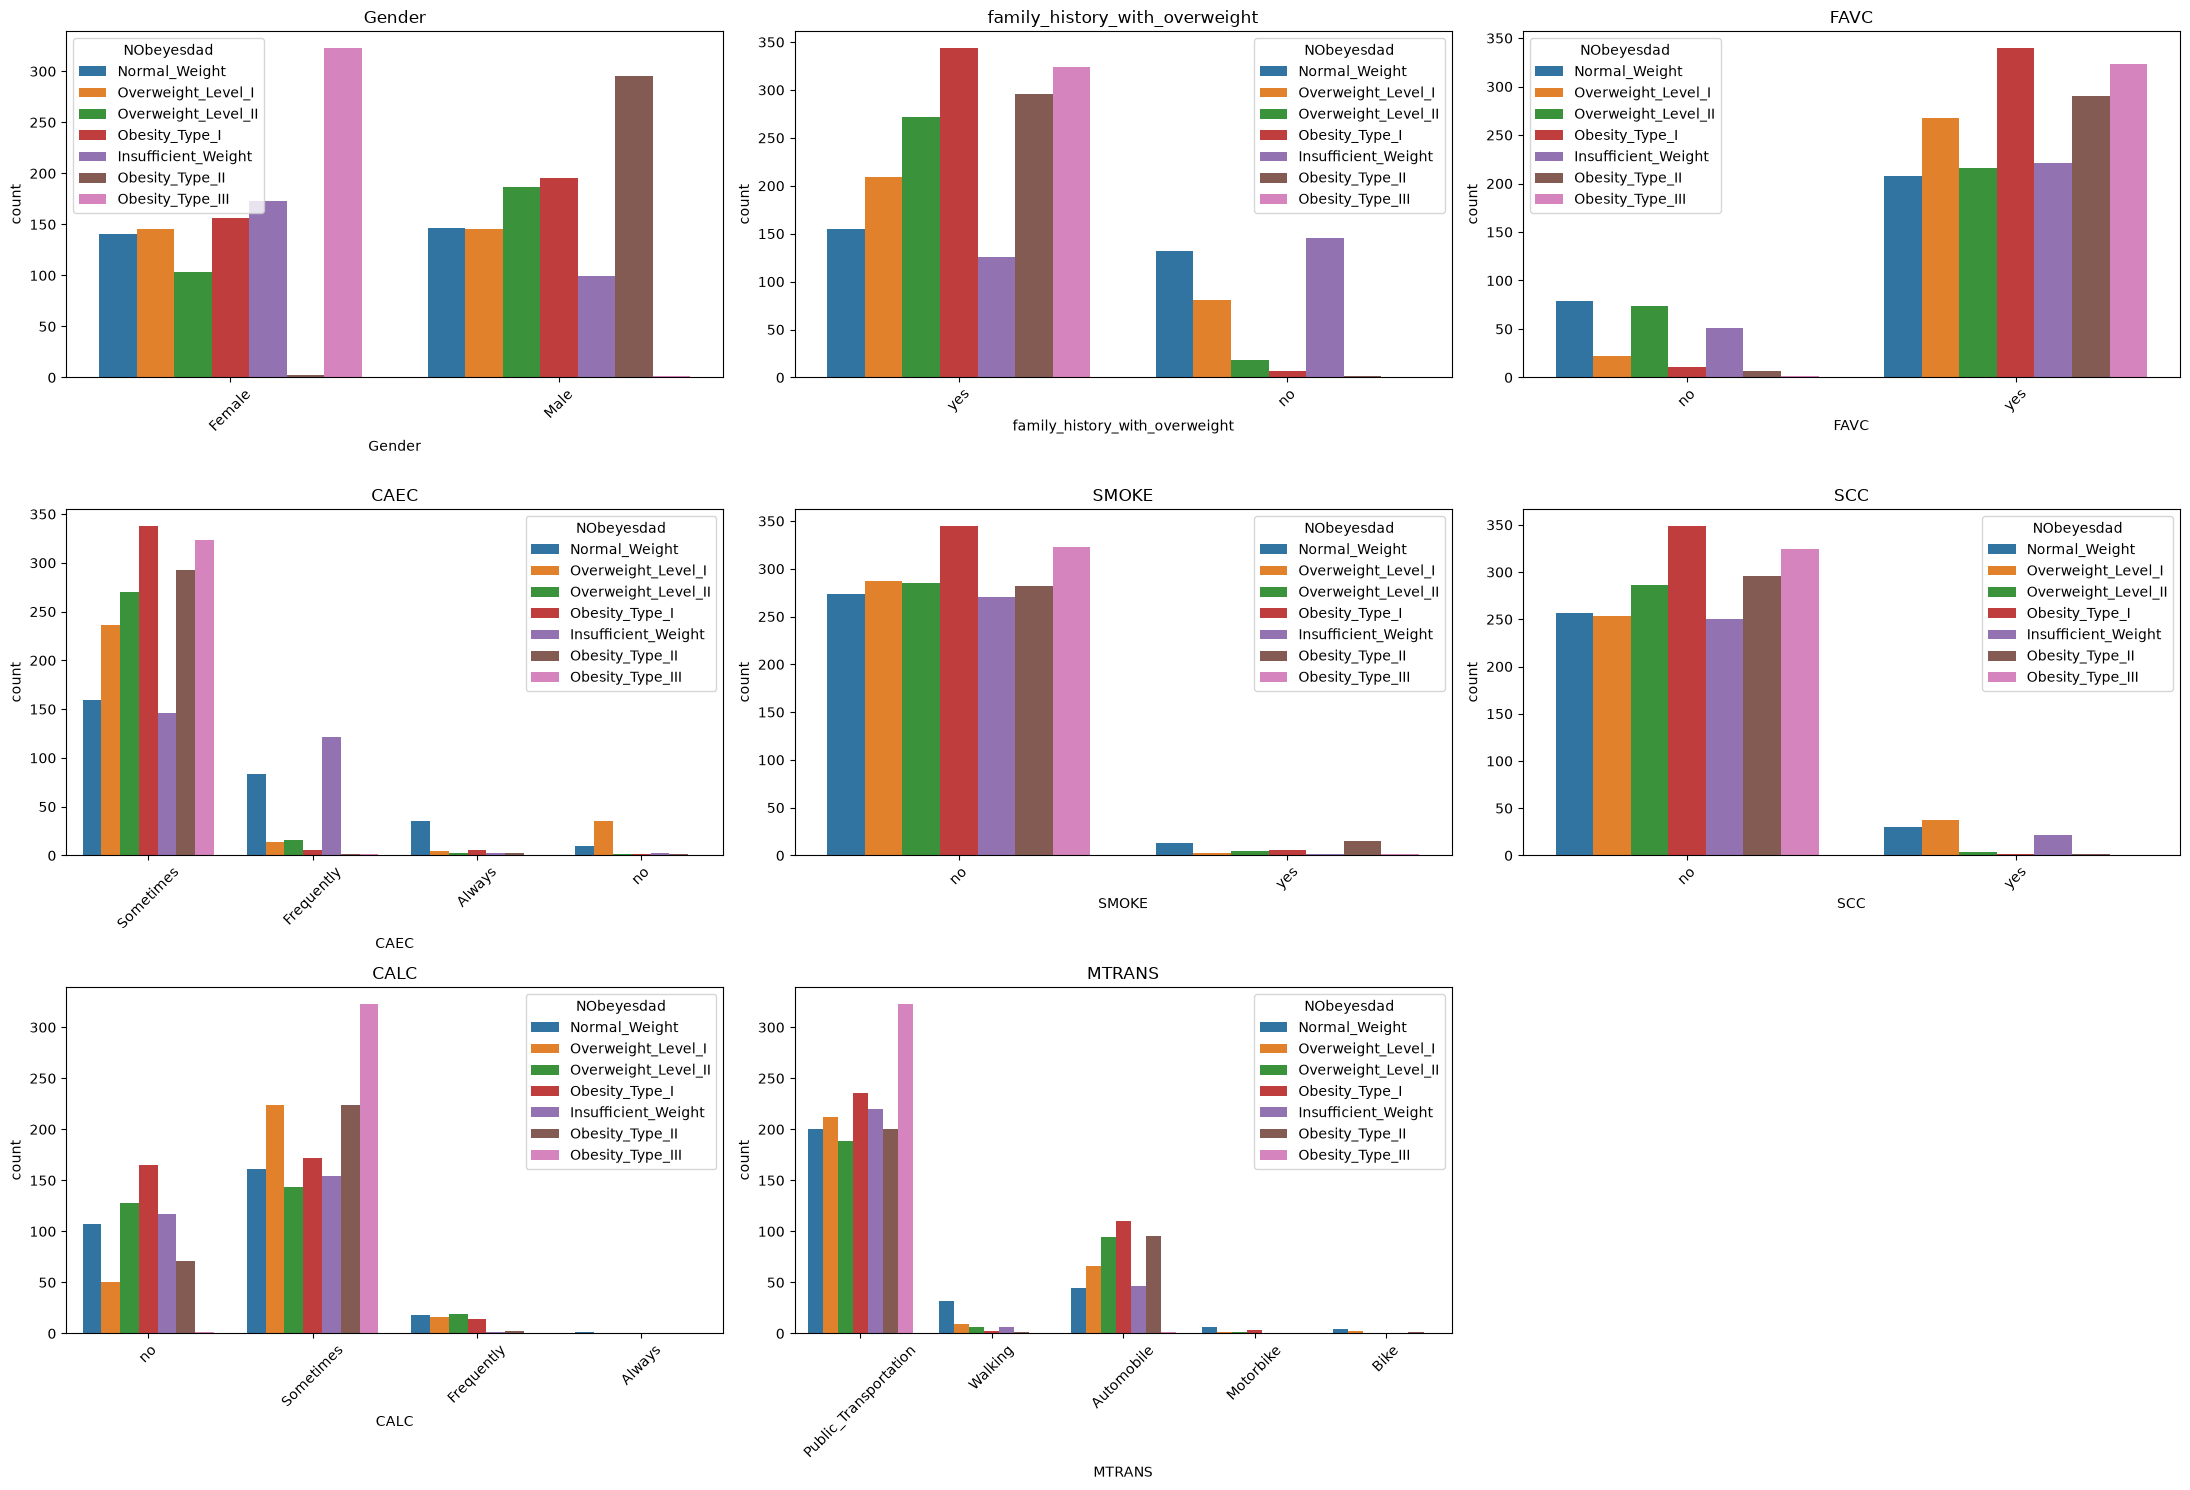

In [13]:
n = len(categorical_cols)
n_cols = 3
n_rows = (n + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(22, n_rows * 5)
)

axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    sns.countplot(
        data=df,
        x=col,
        hue=target_col,
        ax=axes[idx]
    )

    axes[idx].set_title(col)
    axes[idx].tick_params(axis="x", rotation=45)

for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

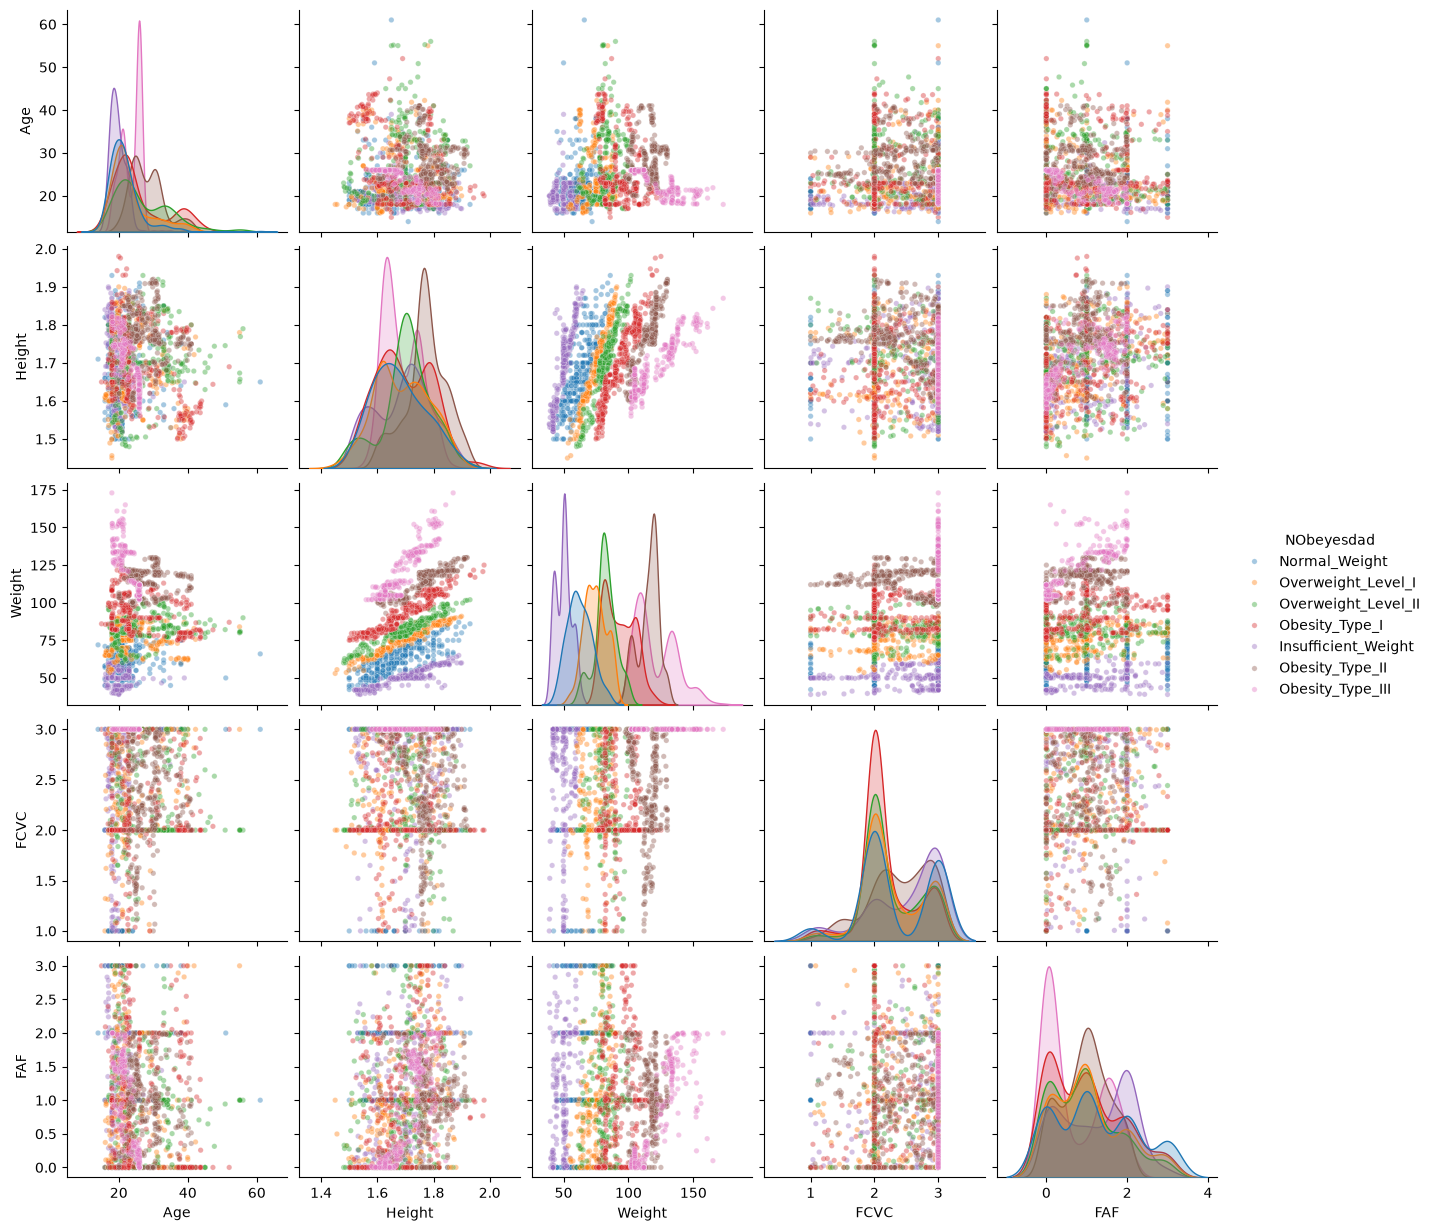

In [14]:
target_col = "NObeyesdad"
features = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "FAF"
]
sns.pairplot(
    df[features + [target_col]],
    hue=target_col,
    plot_kws={
        "alpha": 0.4,
        "s": 15
    }
)
plt.show()

## итог:выбросов нет,потенциально удалить:SMOKE,MTRANS                             

# 3. Подготовка данных

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

feature_cols = [
    "Age",
    "Gender",
    "Height",
    "Weight",
    "CALC",
    "FAVC",
    "FCVC",
    "NCP",
    "SCC",
    "SMOKE",
    "CH2O",
    "family_history_with_overweight",
    "FAF",
    "TUE",
    "CAEC",
    "MTRANS",
    "NObeyesdad"
]
X = df[feature_cols].copy()

X_regres = X.drop(columns=["NObeyesdad"])
y_regres = X["NObeyesdad"].values
X_train_regres, X_test_regres, y_train_regres, y_test_regres = train_test_split(X_regres,y_regres,random_state = 123,stratify = y_regres)

In [16]:
numeric_cols = [
    "Age",
    "Height",
    "Weight",
    "FCVC",
    "NCP",
    "CH2O",
    "FAF",
    "TUE"
]

binary_cols = [
    "Gender",
    "FAVC",
    "SCC",
    "SMOKE",
    "family_history_with_overweight"
]

ordinal_cols = [
    "CALC",
    "CAEC"
]

onehot_cols = [
    "MTRANS"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_cols
        ),
        (
            "binary",
            OrdinalEncoder(
                categories=[
                    ["Female", "Male"],
                    ["no", "yes"],
                    ["no", "yes"],
                    ["no", "yes"],
                    ["no", "yes"]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            binary_cols
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["no", "Sometimes", "Frequently", "Always"],
                    ["no", "Sometimes", "Frequently", "Always"]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            ordinal_cols
        ),
        (
            "mtrans",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            onehot_cols
        )
    ]
)

# 4. Лог регрессия. (1 МОДЕЛЬ)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, log_loss,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=123
    ))
])
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=123)
scores = cross_val_score(pipe,X_train_regres,y_train_regres,cv=cv,scoring="f1_macro")

cv_results = pd.DataFrame({"Fold": [f"Fold {i+1}" for i in range(len(scores))],"F1 Macro": scores})

cv_summary = pd.DataFrame({"Metric": ["CV Mean F1", "CV Std F1"],"Score": [scores.mean(), scores.std()]})

display(cv_results.round(3))
display(cv_summary.round(3))


pipe.fit(X_train_regres, y_train_regres)

y_pred = pipe.predict(X_test_regres)
y_proba = pipe.predict_proba(X_test_regres)

,Fold,F1 Macro
0,Fold 1,0.869
1,Fold 2,0.852
2,Fold 3,0.865
3,Fold 4,0.893
4,Fold 5,0.860


,Metric,Score
0,CV Mean F1,0.868
1,CV Std F1,0.014


In [18]:
# Убираем SMOKE из binary признаков
binary_cols_without = binary_cols[:3] + binary_cols[4:]


# Preprocessing без SMOKE и MTRANS
preprocessor_without = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_cols
        ),

        (
            "binary",
            OrdinalEncoder(
                categories=[
                    ["Female", "Male"],
                    ["no", "yes"],
                    ["no", "yes"],
                    ["no", "yes"]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            binary_cols_without
        ),

        (
            "ordinal",
            OrdinalEncoder(
                categories=[
                    ["no", "Sometimes", "Frequently", "Always"],
                    ["no", "Sometimes", "Frequently", "Always"]
                ],
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            ordinal_cols
        )
    ]
)


# Pipeline без SMOKE и MTRANS
pipe_without = Pipeline([
    ("preprocessor", preprocessor_without),

    ("model", LogisticRegression(
        max_iter=1000,
        random_state=123
    ))
])


# Cross-validation
scores_without = cross_val_score(
    pipe_without,
    X_train_regres,
    y_train_regres,
    cv=cv,
    scoring="f1_macro"
)


# Результаты CV по каждому fold
cv_results_without = pd.DataFrame({
    "Fold": [f"Fold {i+1}" for i in range(len(scores_without))],
    "F1 Macro": scores_without
})

display(cv_results_without.round(3))


# Финальное обучение на всём train
pipe_without.fit(
    X_train_regres,
    y_train_regres
)


# Проверка на test
y_pred_without = pipe_without.predict(X_test_regres)

y_proba_without = pipe_without.predict_proba(X_test_regres)

,Fold,F1 Macro
0,Fold 1,0.868
1,Fold 2,0.869
2,Fold 3,0.865
3,Fold 4,0.893
4,Fold 5,0.876


In [19]:
comparison = pd.DataFrame({
    "Model": [
        "With SMOKE + MTRANS",
        "Without SMOKE + MTRANS"
    ],

    "CV F1 Mean": [
        scores.mean(),
        scores_without.mean()
    ],

    "CV F1 Std": [
        scores.std(),
        scores_without.std()
    ],

    "Test Accuracy": [
        accuracy_score(y_test_regres, y_pred),
        accuracy_score(y_test_regres, y_pred_without)
    ],

    "Test F1 Macro": [
        f1_score(
            y_test_regres,
            y_pred,
            average="macro"
        ),

        f1_score(
            y_test_regres,
            y_pred_without,
            average="macro"
        )
    ],

    "Test ROC-AUC OvR": [
        roc_auc_score(
            y_test_regres,
            y_proba,
            multi_class="ovr",
            average="macro"
        ),

        roc_auc_score(
            y_test_regres,
            y_proba_without,
            multi_class="ovr",
            average="macro"
        )
    ]
})

display(comparison.round(3))

,Model,CV F1 Mean,CV F1 Std,Test Accuracy,Test F1 Macro,Test ROC-AUC OvR
0,With SMOKE + MTRANS,0.868,0.014,0.873,0.870,0.983
1,Without SMOKE + MTRANS,0.874,0.010,0.869,0.866,0.982


In [20]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test_regres,
    y_pred,
    output_dict=True
)

pd.DataFrame(report).T.round(3)

,precision,recall,f1-score,support
Insufficient_Weight,0.892,0.971,0.930,68.000
Normal_Weight,0.900,0.750,0.818,72.000
Obesity_Type_I,0.939,0.875,0.906,88.000
Obesity_Type_II,0.936,0.986,0.961,74.000
Obesity_Type_III,0.976,1.000,0.988,81.000
Overweight_Level_I,0.722,0.781,0.750,73.000
Overweight_Level_II,0.736,0.736,0.736,72.000
accuracy,0.873,0.873,0.873,0.873
macro avg,0.871,0.871,0.870,528.000
weighted avg,0.875,0.873,0.872,528.000


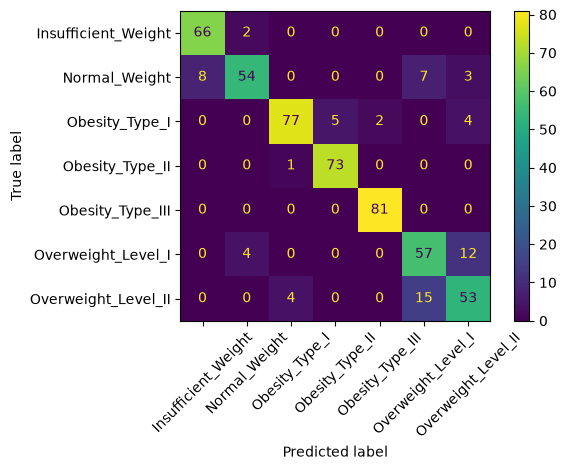

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_regres,
    y_pred,
    xticks_rotation=45
)

plt.tight_layout()
plt.show()

# 4.2 Лог регрессия с L1/L2 or ELasticNet

In [22]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        solver="saga",
        max_iter=5000,
        random_state=123
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
)

param_grid = [
    {
        "model__penalty": ["l1"],
        "model__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "model__penalty": ["l2"],
        "model__C": [0.01, 0.1, 1, 10, 100]
    },
    {
        "model__penalty": ["elasticnet"],
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.25, 0.5, 0.75]
    }
]

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train_regres, y_train_regres)

results = pd.DataFrame(grid.cv_results_)

for penalty in ["l1", "l2", "elasticnet"]:
    part = results[results["param_model__penalty"] == penalty]
    best = part.loc[part["mean_test_score"].idxmax()]

    print(f"\n{penalty.upper()}")
    print("F1 Macro:", round(best["mean_test_score"], 4))
    print("C:", best["param_model__C"])

    if penalty == "elasticnet":
        print("l1_ratio:", best["param_model__l1_ratio"])

# Лучшее L1


L1
F1 Macro: 0.962
C: 10.0

L2
F1 Macro: 0.9528
C: 100.0

ELASTICNET
F1 Macro: 0.9569
C: 100.0
l1_ratio: 0.75


In [23]:
l1_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l1",
        C=10.0,
        solver="saga",
        max_iter=5000,
        random_state=123
    ))
])
l1_model.fit(X_train_regres, y_train_regres)

coef_l1 = l1_model.named_steps["model"].coef_

n1_zero = np.sum(np.isclose(coef_l1, 0))

print("Всего коэффициентов:", coef_l1.size)
print("Нулевых:", n1_zero)
print("Доля нулевых:", n1_zero / coef_l1.size)


Всего коэффициентов: 140
Нулевых: 39
Доля нулевых: 0.2785714285714286


In [24]:
l2_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        penalty="l2",
        C=100.0,
        solver="saga",
        max_iter=5000,
        random_state=123
    ))
])
l2_model.fit(X_train_regres, y_train_regres)

coef_l2 = l2_model.named_steps["model"].coef_

n2_zero = np.sum(np.isclose(coef_l2, 0))

print("Всего коэффициентов:", coef_l2.size)
print("Нулевых:", n2_zero)
print("Доля нулевых:", n2_zero / coef_l2.size)

Всего коэффициентов: 140
Нулевых: 0
Доля нулевых: 0.0


### 5. Дерево решений(3 модель)

In [25]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
tree_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=123
    ))
])
param_grid = {
    "model__max_depth": [3, 5, 7, 10, 15,30],
    "model__min_samples_split": [2, 3, 5, 10],
    "model__min_samples_leaf": [1, 2, 3, 5],
    "model__criterion": ["gini", "entropy"],
    "model__ccp_alpha": [0.0, 0.0001, 0.001, 0.005, 0.01]
}
grid = GridSearchCV(tree_pipe,param_grid=param_grid,cv=cv,scoring="f1_macro",n_jobs=-1)
grid.fit(X_train_regres,y_train_regres)
grid_results = pd.DataFrame({
    "Parameter": [
        "criterion",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "CV F1 Macro"
    ],
    "Value": [
        grid.best_params_["model__criterion"],
        grid.best_params_["model__max_depth"],
        grid.best_params_["model__min_samples_leaf"],
        grid.best_params_["model__min_samples_split"],
        round(grid.best_score_, 3)
    ]
})

display(grid_results)

,Parameter,Value
0,criterion,entropy
1,max_depth,10
2,min_samples_leaf,1
3,min_samples_split,2
4,CV F1 Macro,0.951


In [26]:
print(grid.best_params_)

{'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


In [27]:
best_tree = grid.best_estimator_

y_pred_tree = best_tree.predict(X_test_regres)
y_proba_tree = best_tree.predict_proba(X_test_regres)

tree_test_results = pd.DataFrame({
    "Metric": [
        "CV F1 Macro",
        "Test Accuracy",
        "Test F1 Macro",
        "Test F1 Weighted",
        "Test ROC-AUC OvR"
    ],
    "Score": [
        grid.best_score_,
        accuracy_score(y_test_regres, y_pred_tree),
        f1_score(y_test_regres, y_pred_tree, average="macro"),
        f1_score(y_test_regres, y_pred_tree, average="weighted"),
        roc_auc_score(
            y_test_regres,
            y_proba_tree,
            multi_class="ovr",
            average="macro"
        )
    ]
})

display(tree_test_results.round(3))

,Metric,Score
0,CV F1 Macro,0.951
1,Test Accuracy,0.945
2,Test F1 Macro,0.944
3,Test F1 Weighted,0.945
4,Test ROC-AUC OvR,0.970


,Feature,Importance
2,numeric__Weight,0.617289
1,numeric__Height,0.205402
8,binary__Gender,0.117671
0,numeric__Age,0.020744
9,binary__FAVC,0.011372
5,numeric__CH2O,0.008754
6,numeric__FAF,0.006787
4,numeric__NCP,0.005807
14,ordinal__CAEC,0.003385
12,binary__family_history_with_overweight,0.001437


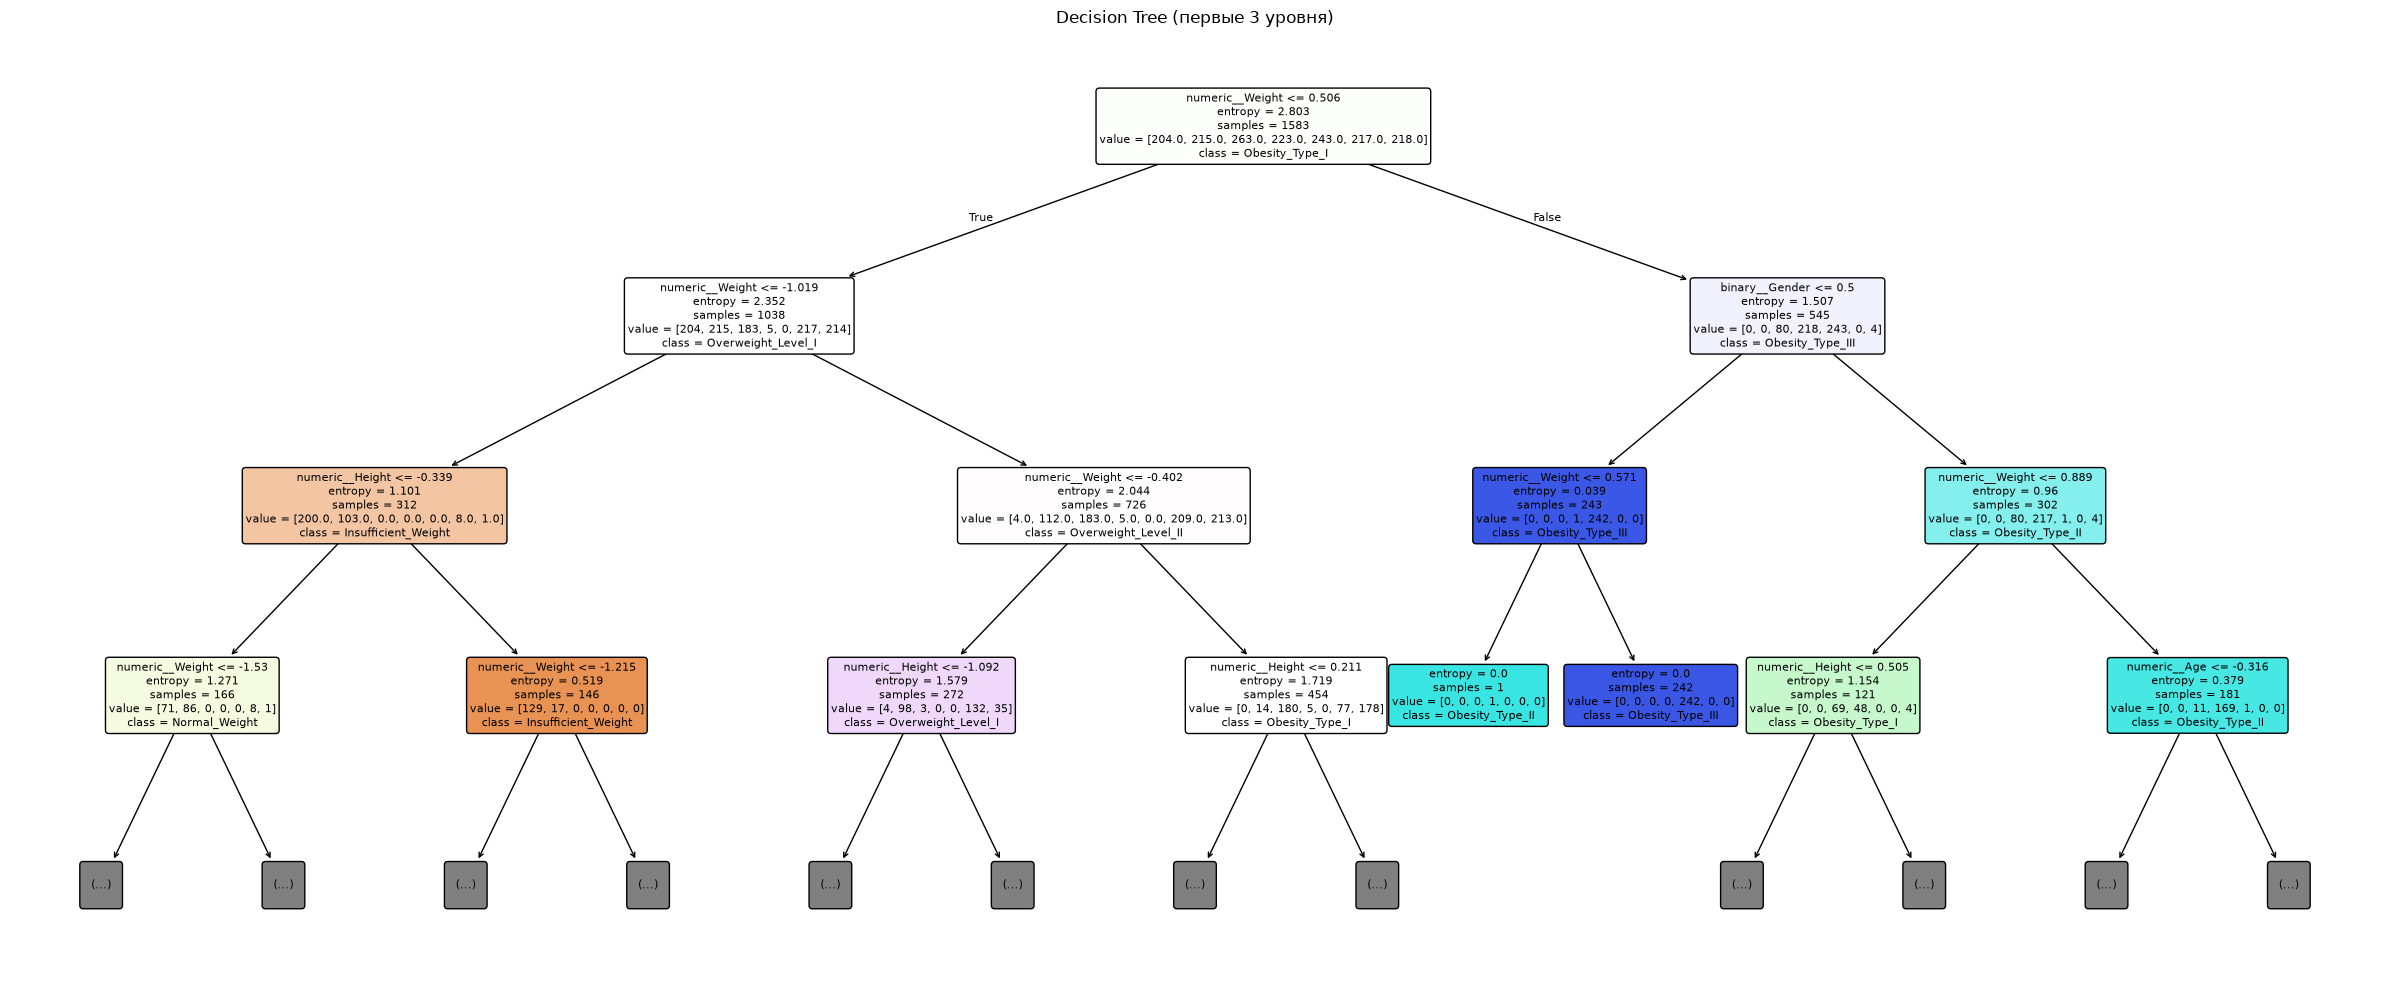

In [28]:
best_tree = grid.best_estimator_.named_steps["model"]

feature_names = (
    grid.best_estimator_
        .named_steps["preprocessor"]
        .get_feature_names_out()
)
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_tree.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance)
class_names = best_tree.classes_.astype(str)
plt.figure(figsize=(24, 10))
plot_tree(best_tree,max_depth=3,feature_names=feature_names,class_names=class_names,filled=True,rounded=True,fontsize=8)
plt.title("Decision Tree (первые 3 уровня)")
plt.tight_layout()
plt.show()
